# 📐 Numerical Differentiation — Numerical Analysis I
**Reference:** Burden & Faires, *Numerical Analysis*, 9th ed. — Chapter 4, Section 4.1–4.2

---
## 📚 Topics Covered

| # | Topic |
|---|-------|
| 1 | Forward, Backward & Centered Difference Formulas |
| 2 | 3-Point & 5-Point Differentiation Formulas |
| 3 | Truncation Error Analysis & Optimal Step Size |
| 4 | Second Derivative Approximation |
| 5 | Richardson's Extrapolation |
| 6 | Error vs. Step Size Visualization |

> **Core Idea:** Approximate $f'(x_0)$ using a finite number of function evaluations, without an analytic formula for the derivative.

In [1]:
# ─────────────────────────────────────────────
# 📦 Imports & Setup
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    'figure.figsize': (11, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})
print('✅ Setup complete.')

✅ Setup complete.


## 1️⃣ Finite Difference Formulas

**Forward Difference**
$$
f'(x_0) \approx \frac{f(x_0+h) - f(x_0)}{h}, \quad O(h)
$$

**Backward Difference**
$$
f'(x_0) \approx \frac{f(x_0) - f(x_0-h)}{h}, \quad O(h)
$$

**Centered Difference**
$$
f'(x_0) \approx \frac{f(x_0+h) - f(x_0-h)}{2h}, \quad O(h^2)
$$

**3-Point Endpoint**
$$
f'(x_0) \approx \frac{-3f(x_0) + 4f(x_0+h) - f(x_0+2h)}{2h}, \quad O(h^2)
$$

**5-Point Midpoint**
$$
f'(x_0) \approx \frac{f(x_0-2h) - 8f(x_0-h) + 8f(x_0+h) - f(x_0+2h)}{12h}, \quad O(h^4)
$$

In [2]:
# ─── First Derivative Formulas ───

def forward_diff(f, x, h):
    """O(h) forward difference: [f(x+h) - f(x)] / h"""
    return (f(x + h) - f(x)) / h

def backward_diff(f, x, h):
    """O(h) backward difference: [f(x) - f(x-h)] / h"""
    return (f(x) - f(x - h)) / h

def centered_diff(f, x, h):
    """O(h²) centered (3-point midpoint): [f(x+h) - f(x-h)] / (2h)"""
    return (f(x + h) - f(x - h)) / (2 * h)

def three_point_endpoint(f, x, h):
    """O(h²) 3-point endpoint formula"""
    return (-3*f(x) + 4*f(x + h) - f(x + 2*h)) / (2 * h)

def five_point_midpoint(f, x, h):
    """O(h⁴) 5-point midpoint formula — highest accuracy single-derivative formula"""
    return (f(x - 2*h) - 8*f(x - h) + 8*f(x + h) - f(x + 2*h)) / (12 * h)

def second_derivative_centered(f, x, h):
    """O(h²) centered second derivative: [f(x+h) - 2f(x) + f(x-h)] / h²"""
    return (f(x + h) - 2*f(x) + f(x - h)) / h**2

print('✅ All differentiation formulas defined.')

✅ All differentiation formulas defined.


In [3]:
# ── Demonstration: f(x) = sin(x),  x₀ = π/4 ──
# True derivative: f'(π/4) = cos(π/4) = √2/2 ≈ 0.70710678

f = np.sin
df_true = np.cos   # true derivative
x0 = np.pi / 4
true_val = df_true(x0)
h = 0.1

methods = {
    'Forward  O(h)':      forward_diff(f, x0, h),
    'Backward O(h)':      backward_diff(f, x0, h),
    'Centered O(h²)':     centered_diff(f, x0, h),
    '3-Pt Endpoint O(h²)': three_point_endpoint(f, x0, h),
    '5-Pt Midpoint O(h⁴)': five_point_midpoint(f, x0, h),
}

print(f"\n📌 f(x) = sin(x),  x₀ = π/4,  h = {h}")
print(f"   True f'(π/4) = cos(π/4) = {true_val:.12f}\n")
print(f"{'Method':<28} {'Approximation':>16} {'Abs Error':>14} {'Rel Error':>12}")
print("-" * 74)
for name, approx in methods.items():
    abs_err = abs(approx - true_val)
    rel_err = abs_err / abs(true_val)
    print(f"{name:<28} {approx:>16.12f} {abs_err:>14.2e} {rel_err:>12.2e}")


📌 f(x) = sin(x),  x₀ = π/4,  h = 0.1
   True f'(π/4) = cos(π/4) = 0.707106781187

Method                          Approximation      Abs Error    Rel Error
--------------------------------------------------------------------------
Forward  O(h)                  0.670602972904       3.65e-02     5.16e-02
Backward O(h)                  0.741254745096       3.41e-02     4.83e-02
Centered O(h²)                 0.705928859000       1.18e-03     1.67e-03
3-Pt Endpoint O(h²)            0.709279080617       2.17e-03     3.07e-03
5-Pt Midpoint O(h⁴)            0.707104426968       2.35e-06     3.33e-06


---
## 2️⃣ Truncation Error vs. Roundoff Error

There's a fundamental **trade-off** when choosing step size $h$:

- **Truncation error** decreases as $h \to 0$ (formula gets more accurate)
- **Roundoff error** increases as $h \to 0$ (catastrophic cancellation in $f(x+h) - f(x)$)

For the $O(h^2)$ centered formula, total error is:
$$E_{\text{total}}(h) \approx \frac{2\varepsilon}{h} + \frac{M_3}{6}h^2$$

The **optimal step size** minimizing total error is:
$$h_{\text{opt}} = \left(\frac{6\varepsilon}{M_3}\right)^{1/3}$$

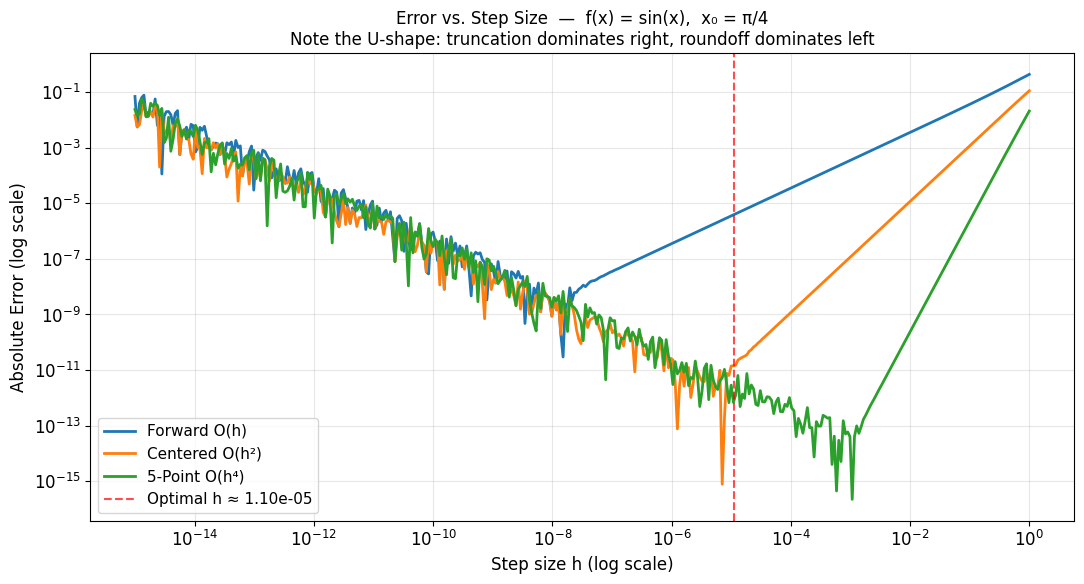


🔍 Machine epsilon  ε  = 2.2204e-16
   Optimal h (theory) = 0.000011


In [4]:
# ── Error vs. Step Size for f(x) = sin(x) at x₀ = π/4 ──
h_vals = np.logspace(-15, 0, 400)   # from 1e-15 to 1

err_forward  = [abs(forward_diff(f, x0, h)  - true_val) for h in h_vals]
err_centered = [abs(centered_diff(f, x0, h) - true_val) for h in h_vals]
err_5pt      = [abs(five_point_midpoint(f, x0, h) - true_val) for h in h_vals]

# Analytical optimal h for centered difference (M3 = |sin(π/4)| = 1/√2)
epsilon = np.finfo(float).eps   # machine epsilon ≈ 2.22e-16
M3 = 1.0  # max |sin(x)|
h_opt = (6 * epsilon / M3) ** (1/3)

fig, ax = plt.subplots(figsize=(11, 6))
ax.loglog(h_vals, err_forward,  label='Forward O(h)',       linewidth=2)
ax.loglog(h_vals, err_centered, label='Centered O(h²)',     linewidth=2)
ax.loglog(h_vals, err_5pt,      label='5-Point O(h⁴)',      linewidth=2)
ax.axvline(h_opt, color='red', linestyle='--', alpha=0.7, label=f'Optimal h ≈ {h_opt:.2e}')

ax.set_xlabel('Step size h (log scale)')
ax.set_ylabel('Absolute Error (log scale)')
ax.set_title("Error vs. Step Size  —  f(x) = sin(x),  x₀ = π/4\n"
             "Note the U-shape: truncation dominates right, roundoff dominates left", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n🔍 Machine epsilon  ε  = {epsilon:.4e}")
print(f"   Optimal h (theory) = {h_opt:.6f}")

---
## 3️⃣ Richardson's Extrapolation

**Idea:** Combine two approximations at different step sizes to cancel the leading error term, boosting accuracy from $O(h^2)$ to $O(h^4)$:

$$N_2(h) = \frac{4N_1(h/2) - N_1(h)}{3} \implies O(h^4)$$

**Key insight:** This $O(h^4)$ result is *identical* to the 5-point midpoint formula.

In [5]:
def richardson_extrapolation(f, x, h, order=1):
    """
    Richardson's Extrapolation for first derivative.

    Parameters:
    -----------
    f     : callable — function f(x)
    x     : float   — point of differentiation
    h     : float   — initial step size
    order : int     — number of extrapolation levels (default: 1)

    Returns:
    --------
    float — extrapolated derivative approximation
    """
    # Build Richardson table using centered differences as base
    N = np.zeros((order + 1, order + 1))
    for i in range(order + 1):
        N[i, 0] = centered_diff(f, x, h / 2**i)  # column 0: O(h²) approx at half-step

    # Fill extrapolation table
    for j in range(1, order + 1):
        for i in range(j, order + 1):
            N[i, j] = (4**j * N[i, j-1] - N[i-1, j-1]) / (4**j - 1)

    return N, N[order, order]


# ── Demo ──
h = 0.5
N_table, best = richardson_extrapolation(np.sin, np.pi/4, h, order=4)

print(f"\n📌 Richardson Extrapolation Table — f(x) = sin(x), x₀ = π/4, h = {h}")
print(f"   True value = {true_val:.15f}\n")
df_rich = pd.DataFrame(N_table)
df_rich.columns = [f'O(h^{2*(j+1)})' for j in range(df_rich.shape[1])]
df_rich.index   = [f'h/{2**i}' for i in range(df_rich.shape[0])]
print(df_rich.to_string(float_format='{:.15f}'.format))
print(f"\n   Best estimate = {best:.15f}")
print(f"   Error         = {abs(best - true_val):.4e}")


📌 Richardson Extrapolation Table — f(x) = sin(x), x₀ = π/4, h = 0.5
   True value = 0.707106781186548

                O(h^2)            O(h^4)            O(h^6)            O(h^8)           O(h^10)
h/1  0.678010098842090 0.000000000000000 0.000000000000000 0.000000000000000 0.000000000000000
h/2  0.699764069125094 0.707015392552762 0.000000000000000 0.000000000000000 0.000000000000000
h/4  0.705266795354555 0.707101037431041 0.707106747089593 0.000000000000000 0.000000000000000
h/8  0.706646515114127 0.707106421700652 0.707106780651959 0.707106781184695 0.000000000000000
h/16 0.706991697811663 0.707106758710842 0.707106781178188 0.707106781186540 0.707106781186548

   Best estimate = 0.707106781186548
   Error         = 0.0000e+00


---
## 4️⃣ Step-by-Step Error Analysis Table

Compare all formulas at multiple step sizes to empirically confirm the convergence orders.

In [6]:
# ── Error convergence table across h values ──
h_list = [0.1, 0.05, 0.025, 0.01, 0.005, 0.001]

rows = []
for h in h_list:
    e1 = abs(centered_diff(f, x0, h) - true_val)
    e2 = abs(five_point_midpoint(f, x0, h) - true_val)
    _, r1 = richardson_extrapolation(f, x0, h, order=1)
    e3 = abs(r1 - true_val)
    rows.append([h, e1, e2, e3])

df_err = pd.DataFrame(rows, columns=['h', 'Centered O(h²)', '5-Pt O(h⁴)', 'Richardson O(h⁴)'])
print("\n📊 Error Convergence Table — f(x) = sin(x), x₀ = π/4")
print(df_err.to_string(index=False, float_format='{:.4e}'.format))

# Compute empirical order of convergence
errs_c = [row[1] for row in rows]
print("\n   Empirical convergence order (Centered):")
for i in range(1, len(errs_c)):
    ratio = h_list[i-1] / h_list[i]
    if errs_c[i] > 0 and errs_c[i-1] > 0:
        order = np.log(errs_c[i-1] / errs_c[i]) / np.log(ratio)
        print(f"   h={h_list[i]:.3f}: order ≈ {order:.2f}")


📊 Error Convergence Table — f(x) = sin(x), x₀ = π/4
         h  Centered O(h²)  5-Pt O(h⁴)  Richardson O(h⁴)
1.0000e-01      1.1779e-03  2.3542e-06        1.4727e-07
5.0000e-02      2.9459e-04  1.4727e-07        9.2064e-09
2.5000e-02      7.3655e-05  9.2064e-09        5.7544e-10
1.0000e-02      1.1785e-05  2.3570e-10        1.4722e-11
5.0000e-03      2.9463e-06  1.4730e-11        9.5546e-13
1.0000e-03      1.1785e-07  6.6613e-15        1.0436e-13

   Empirical convergence order (Centered):
   h=0.050: order ≈ 2.00
   h=0.025: order ≈ 2.00
   h=0.010: order ≈ 2.00
   h=0.005: order ≈ 2.00
   h=0.001: order ≈ 2.00


---
## 🧪 Practice Problems

1. Compute $f'(1.5)$ for $f(x) = x \ln(x)$ using all five formulas with $h = 0.1$. Compare to the exact value.
2. For $f(x) = e^{-x^2}$, find the optimal $h$ for the centered difference formula and verify numerically.
3. Use Richardson's Extrapolation with 3 levels to approximate $f'(2)$ for $f(x) = \sqrt{x}$.
4. Plot the error vs. $h$ curve for the 5-point formula applied to $f(x) = \cos(x)$ at $x = \pi/3$.
5. **Challenge:** Derive the 5-point formula for the second derivative $f''(x_0)$.